# First Implementation 


>>There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


### Import


In [1]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Notebook utility functions




---
### Convert to frame, create a list of these frames

In [4]:
import convert_video_frame
VIDEO_PATH = Path(r"C:\Users\conqu\Downloads\Real_porsche.mp4")
FRAMES_OUTPUT_DIR = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30")
IMAGE_OUTPUT_DIR = PROJECT_ROOT / "image"
IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if FRAMES_OUTPUT_DIR.exists():
    for existing_file in FRAMES_OUTPUT_DIR.glob("*.png"):
        existing_file.unlink()
else:
    FRAMES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise ValueError(f"Impossible d'ouvrir la video : {VIDEO_PATH}")

fps = float(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
max_frames = 30
saved_idx = 0

print(f"Video source : {VIDEO_PATH}")
print(f"FPS : {fps}")
print(f"Nombre total de trames dans la video : {frame_count}")
print(f"Extraction des {max_frames} premieres frames vers : {FRAMES_OUTPUT_DIR}")

while saved_idx < max_frames:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_path = FRAMES_OUTPUT_DIR / f"frame_{saved_idx:05d}.png"
    if not convert_video_frame.save_frame(frame_path, gray_frame):
        cap.release()
        raise IOError(f"Echec de l'ecriture de l'image : {frame_path}")

    saved_idx += 1

cap.release()
print(f"{saved_idx} frames sauvegardees dans : {FRAMES_OUTPUT_DIR}")

if saved_idx < 3:
    raise ValueError("Il faut au moins 3 frames pour estimer les intrinseques.")


Video source : C:\Users\conqu\Downloads\Real_porsche.mp4
FPS : 25.0
Nombre total de trames dans la video : 160
Extraction des 30 premieres frames vers : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30
30 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30


In [5]:
dossier_fake = FRAMES_OUTPUT_DIR

In [6]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*.png")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouves dans {dossier_fake}")

if len(fake_frame_paths) != 30:
    raise ValueError(f"Le dossier de travail doit contenir exactement 30 frames, obtenu: {len(fake_frame_paths)}")


30 fichiers trouves dans C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30


In [7]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00001.png


Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.

In [8]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


### Extract keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [9]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


xFormers not available


xFormers not available


Depth Anything loaded on cpu (97.47M parameters)


In [10]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00000.png
keyframe_image shape = (360, 640) dtype = uint8
keyframe_depth shape = (360, 640) dtype = float32
depth min/max = 0.0 61.06563186645508
valid depth ratio = 0.9918055555555556


Text(0.5, 1.0, 'Inverse depth')

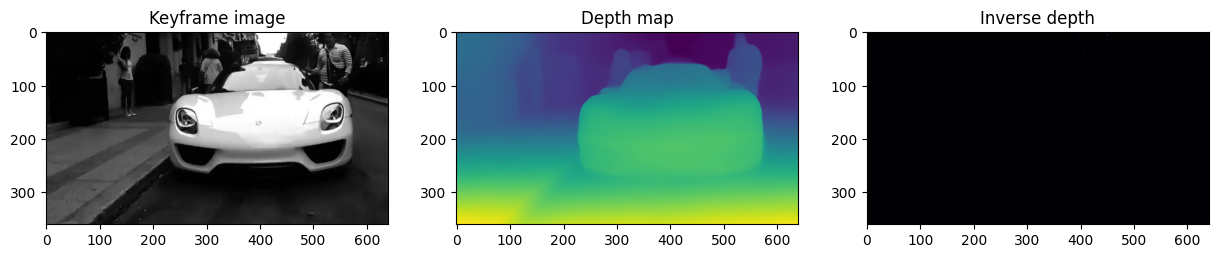

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




### **Intrinsics estimated from Real_porsche.mp4**


Les intrinseques sont estimees automatiquement une seule fois a partir de 3 frames reparties sur les **30 premieres images** de `Real_porsche.mp4`.
Le resultat alimente ensuite **tout le notebook** et la boucle sequence complete.



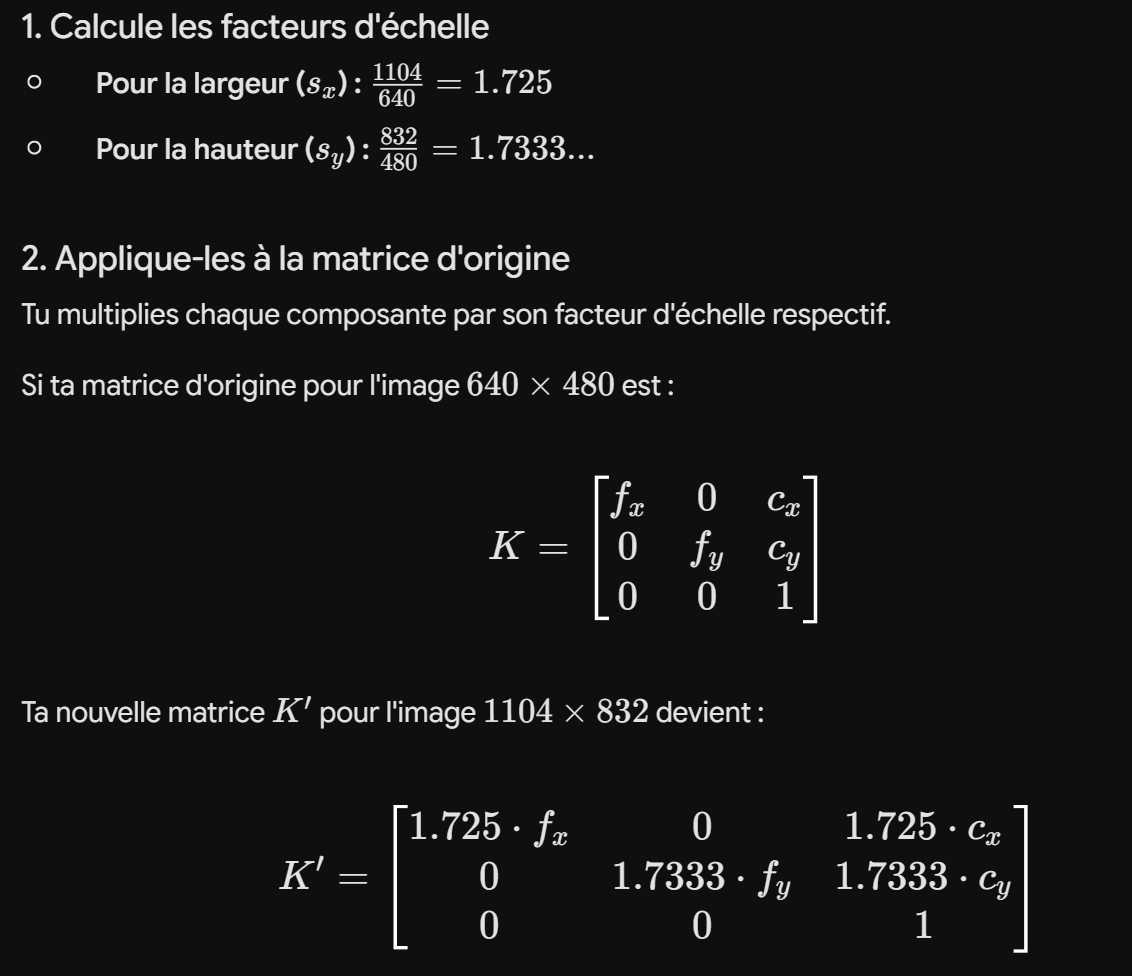

In [12]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

In [13]:
# ==================================================
# Intrinseques estimees UNE FOIS au debut
# ==================================================
from estimate_intrinsics import estimate_camera_intrinsics_from_frames

loaded_height, loaded_width = keyframe_image.shape[:2]
frames_for_intrinsics = fake_frame_paths[:30]

candidate_index_sets = []
if len(frames_for_intrinsics) >= 30:
    candidate_index_sets.extend(
        [
            [0, 10, 20],
            [0, 14, 29],
            [5, 15, 25],
            [0, 1, 2],
        ]
    )

candidate_index_sets.append(np.linspace(0, len(frames_for_intrinsics) - 1, 3, dtype=int).tolist())

estimated_K = None
used_intrinsic_paths = None
last_error = None

for raw_indices in candidate_index_sets:
    candidate_indices = [int(min(max(index, 0), len(frames_for_intrinsics) - 1)) for index in raw_indices]
    if len(set(candidate_indices)) < 3:
        continue

    sample_paths = [normalize_image_path(frames_for_intrinsics[index]) for index in candidate_indices]
    sample_frames = [load_gray_image(path) for path in sample_paths]

    try:
        estimated_K = estimate_camera_intrinsics_from_frames(sample_frames)
        used_intrinsic_paths = sample_paths
        break
    except Exception as exc:
        print(f"Echec estimation intrinseques avec indices {candidate_indices}: {exc}")
        last_error = exc

if estimated_K is None:
    raise RuntimeError(f"Impossible d'estimer les intrinseques pour Real_porsche.mp4. Derniere erreur: {last_error}")

USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height
USER_FX = float(estimated_K[0, 0])
USER_FY = float(estimated_K[1, 1])
USER_CX = float(estimated_K[0, 2])
USER_CY = float(estimated_K[1, 2])

intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array(
    [
        [USER_FX, 0.0, USER_CX],
        [0.0, USER_FY, USER_CY],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array(
    [
        [cam.fx[0], 0.0, cam.cx[0]],
        [0.0, cam.fy[0], cam.cy[0]],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("Frames utilisees pour estimer les intrinseques:")
for path in used_intrinsic_paths:
    print(" ", path)
print()
print("Intrinseques estimees au debut du notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 640
  height = 360

Frames utilisees pour estimer les intrinseques:
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00000.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00010.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00020.png

Intrinseques estimees au debut du notebook:
{'width': 640, 'height': 360, 'fx': 1901.7310953275573, 'fy': 1901.7310953275573, 'cx': 320.0, 'cy': 180.0}

K_user =
[[1901.731095    0.        320.      ]
 [   0.       1901.731095  180.      ]
 [   0.          0.          1.      ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[1901.731095    0.        320.      ]
 [   0.       2535.64146   240.      ]
 [   0.          0.          1.      ]

In [14]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 1.0
  scale_y = 1.3333333333333333

  USER_FX -> cam.fx[0] : 1901.7310953275573 -> 1901.7310953275573
  USER_FY -> cam.fy[0] : 1901.7310953275573 -> 2535.641460436743
  USER_CX -> cam.cx[0] : 320.0 -> 320.0
  USER_CY -> cam.cy[0] : 180.0 -> 240.0

Expected level-0 values after internal resize:
  expected fx = 1901.7310953275573
  expected fy = 2535.641460436743
  expected cx = 320.0
  expected cy = 240.0

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [15]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 1901.731095, 2535.641460
  cx, cy = 320.000000, 240.000000
  K =
[[1901.731095    0.        320.      ]
 [   0.       2535.64146   240.      ]
 [   0.          0.          1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 950.865548, 1267.820730
  cx, cy = 160.000000, 120.000000
  K =
[[ 950.865548    0.        160.      ]
 [   0.       1267.82073   120.      ]
 [   0.          0.          1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 475.432774, 633.910365
  cx, cy = 80.000000, 60.000000
  K =
[[475.432774   0.        80.      ]
 [  0.       633.910365  60.      ]
 [  0.         0.         1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 237.716387, 316.955183
  cx, cy = 40.000000, 30.000000
  K =
[[237.716387   0.        40.      ]
 [  0.       316.955183  30.      ]
 [  0.         0.         1.      ]]

LEVEL 4
  scale  = 1 / 1

In [16]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


### Extract the the current image




Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.

In [17]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

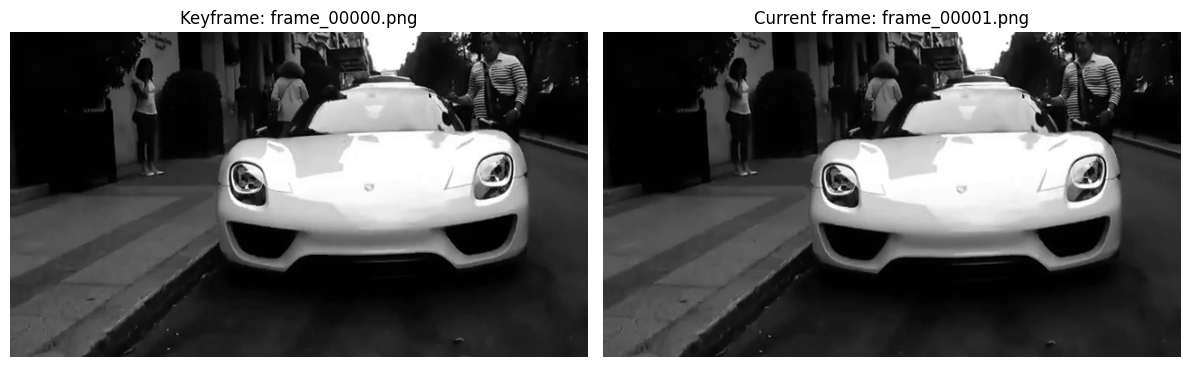

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
### **Initial pose and optimization updates**

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [19]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 1901.7310953275573
  pose_solver.camera.fy[0] = 2535.641460436743
  pose_solver.camera.cx[0] = 320.0
  pose_solver.camera.cy[0] = 240.0

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 1901.7310953275573, 'fy': 2535.641460436743, 'cx': 320.0, 'cy': 240.0}



Initial photometric errors before optimization:
  level 4 = 267.32573599240266
  level 3 = 205.60847268673356
  level 2 = 270.77786757179007


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [20]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  267.32573599240266


 error improvement too small, level converged! it:  4  error:  201.86131982977838  lambda:  12.8
lvl:  3  initial error:  166.3290610079863


update too small, level converged! it:  3  error:  146.9479641567369  lambda:  56294995342131.2
lvl:  2  initial error:  125.83971307933136


 error improvement too small, level converged! it:  2  error:  119.6458187058666  lambda:  1759218604441.6


Final photometric errors after optimization:
  level 4 = 204.52110552309875
  level 3 = 148.34369028513527
  level 2 = 119.6458187058666


#### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [21]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."

if all(errors_improved.values()):
    print()
    print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")
else:
    print()
    print("Warning: at least one pyramid level did not improve, but the pose matrix remains finite. Execution continues for sequence-level analysis.")


Optimization summary:
  level 4: initial=267.325736, final=204.521106, improvement=62.804630
  level 3: initial=205.608473, final=148.343690, improvement=57.264782
  level 2: initial=270.777868, final=119.645819, improvement=151.132049

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [22]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999998 -0.002106  0.000016  0.000462]
 [ 0.002106  0.999997  0.000826 -0.001464]
 [-0.000018 -0.000826  1.       -0.006977]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [23]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[ 0.   -0.    0.    0.02]
 [ 0.    0.    0.01  0.02]
 [-0.   -0.01  0.   -0.01]
 [ 0.    0.    0.    0.  ]]


----------- 

---
### **x'=HX (core of the NoteBook)**

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [24]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


---
### Evaluation

In [25]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [26]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 23404278.0


In [27]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 301470
  difference > 200         = 0
  150 <= difference <= 200 = 21
  100 <= difference < 150  = 140
   50 <= difference < 100  = 1873
   30 <= difference < 50   = 3946
   10 <= difference < 30   = 16911
    0 <= difference < 10   = 278579


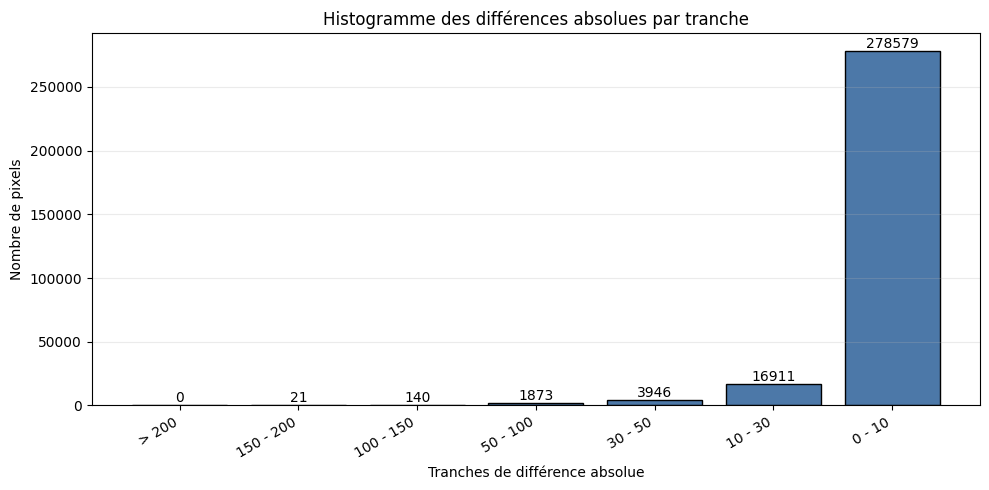

In [28]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


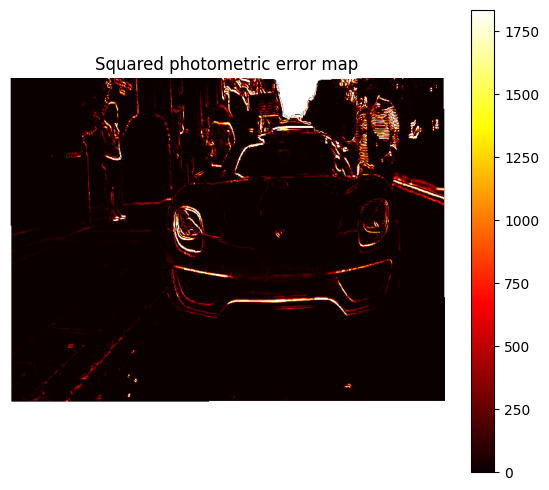

In [29]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [30]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
### **Scale sur toutes les images**

In [31]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real_porsche_frames_first30\frame_00000.png


Sequence real_porsche_first30:
  source size = 640 x 360
  working size level-0 = 640 x 480
  fx level-0 = 1901.7310953275573
  fy level-0 = 2535.641460436743



[real_porsche_first30] frame 0 -> keyframe de reference: frame_00000.png


lvl:  4  initial error:  267.32573599240266


 error improvement too small, level converged! it:  4  error:  201.86131982977838  lambda:  12.8
lvl:  3  initial error:  166.3290610079863


update too small, level converged! it:  3  error:  146.9479641567369  lambda:  56294995342131.2
lvl:  2  initial error:  125.83971307933136


 error improvement too small, level converged! it:  2  error:  119.6458187058666  lambda:  1759218604441.6


[real_porsche_first30] frame 1 -> frame_00001.png | sum error = 23404278.00 | mean abs error = 3.1474 | valid pixels = 301470


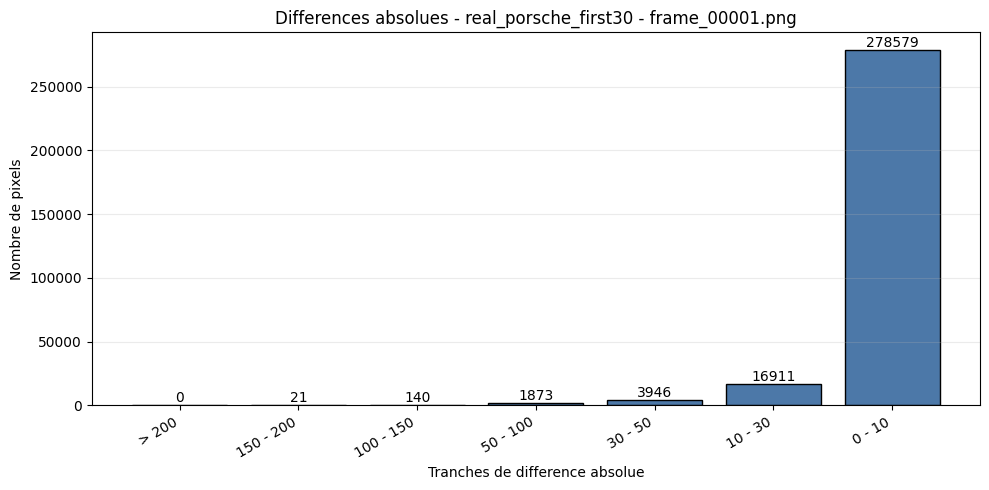

lvl:  4  initial error:  600.3523266856597


update too small, level converged! it:  5  error:  397.1415783320107  lambda:  28147497671065.6
lvl:  3  initial error:  270.3421579296482


 error improvement too small, level converged! it:  4  error:  226.6337862228305  lambda:  12.8


lvl:  2  initial error:  189.99567621074436


 error improvement too small, level converged! it:  3  error:  181.76512341641853  lambda:  1.6


[real_porsche_first30] frame 2 -> frame_00002.png | sum error = 56401308.00 | mean abs error = 5.1579 | valid pixels = 299667


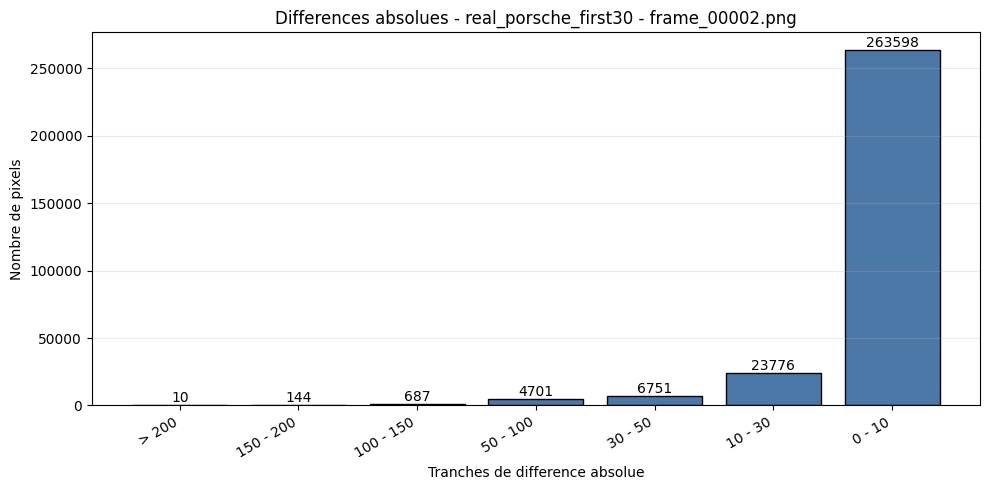

lvl:  4  initial error:  787.2497625830955


 error improvement too small, level converged! it:  6  error:  437.80065358805706  lambda:  1.6
lvl:  3  initial error:  272.23881731550745


 error improvement too small, level converged! it:  2  error:  241.75106377328132  lambda:  3518437208883.2


lvl:  2  initial error:  242.8709262253083


 error improvement too small, level converged! it:  2  error:  241.35483300586964  lambda:  12.8


[real_porsche_first30] frame 3 -> frame_00003.png | sum error = 82428768.00 | mean abs error = 6.4926 | valid pixels = 294015


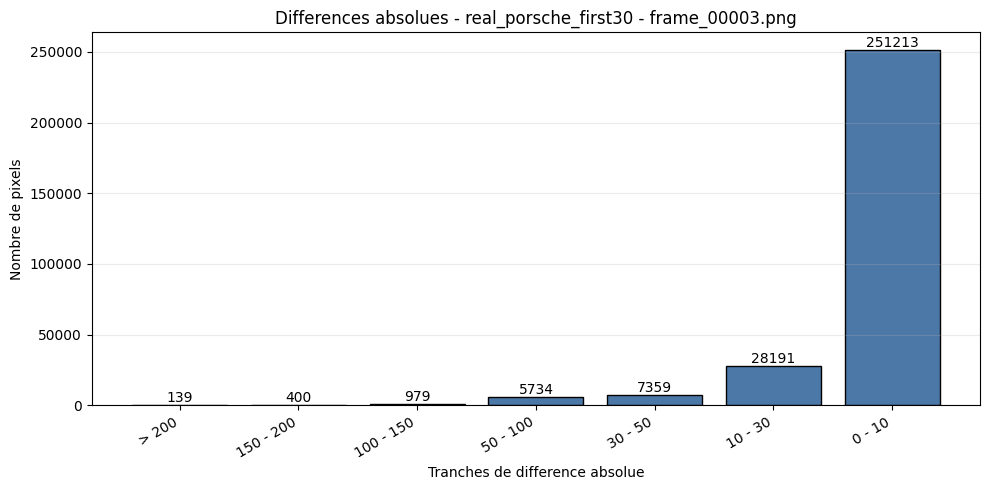

lvl:  4  initial error:  889.5982905982902


 error improvement too small, level converged! it:  5  error:  438.0953020288213  lambda:  879609302220.8
lvl:  3  initial error:  314.1481313294772


 error improvement too small, level converged! it:  2  error:  313.40953831544516  lambda:  819.2


lvl:  2  initial error:  297.4834234526292


 error improvement too small, level converged! it:  4  error:  286.3418460871957  lambda:  1.6


[real_porsche_first30] frame 4 -> frame_00004.png | sum error = 94911560.00 | mean abs error = 7.2231 | valid pixels = 289444


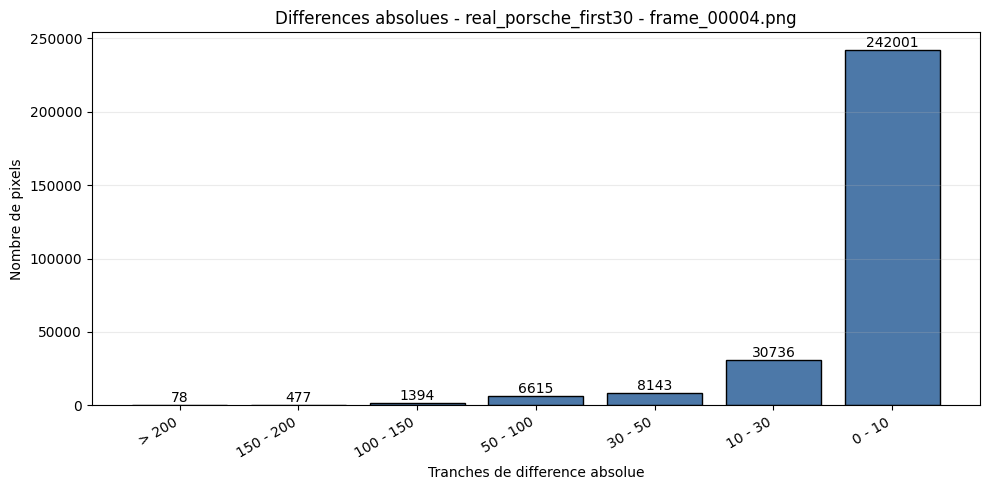

lvl:  4  initial error:  1015.6324786324782


 error improvement too small, level converged! it:  5  error:  459.57255857302374  lambda:  0.2
lvl:  3  initial error:  380.7984365093804


 error improvement too small, level converged! it:  2  error:  380.18113781242903  lambda:  25.6


lvl:  2  initial error:  288.89818403827445


 error improvement too small, level converged! it:  2  error:  283.5975497587892  lambda:  0.0


[real_porsche_first30] frame 5 -> frame_00005.png | sum error = 101935248.00 | mean abs error = 7.3967 | valid pixels = 283812


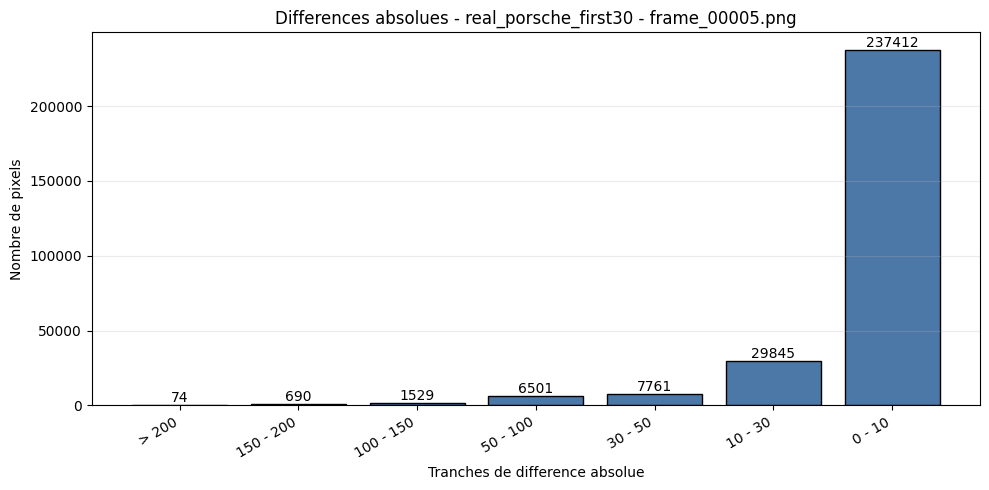

lvl:  4  initial error:  1082.4624881291543


 error improvement too small, level converged! it:  5  error:  479.70519410526583  lambda:  0.0
lvl:  3  initial error:  398.2916869010997


 error improvement too small, level converged! it:  2  error:  396.4646384402222  lambda:  3.2
lvl:  2  initial error:  361.35272921972853


 error improvement too small, level converged! it:  2  error:  353.95216286583815  lambda:  0.0


[real_porsche_first30] frame 6 -> frame_00006.png | sum error = 120443944.00 | mean abs error = 8.1954 | valid pixels = 281994


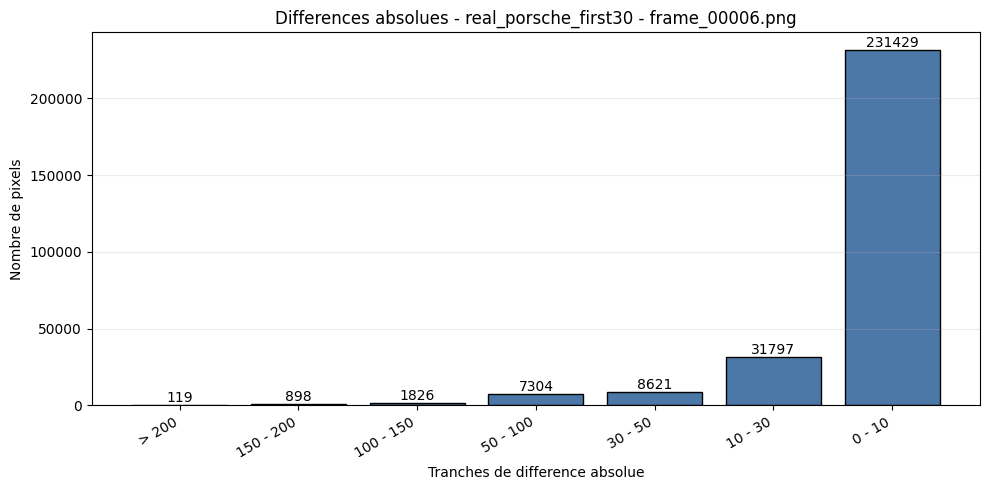

lvl:  4  initial error:  1070.4681861348524


 error improvement too small, level converged! it:  7  error:  475.9823854480046  lambda:  51.2
lvl:  3  initial error:  395.1059470220385


 error improvement too small, level converged! it:  2  error:  381.92121828441253  lambda:  0.4


lvl:  2  initial error:  427.2169005215613


update too small, level converged! it:  2  error:  425.86384464987947  lambda:  28147497671065.6


[real_porsche_first30] frame 7 -> frame_00007.png | sum error = 139922480.00 | mean abs error = 9.1011 | valid pixels = 282048


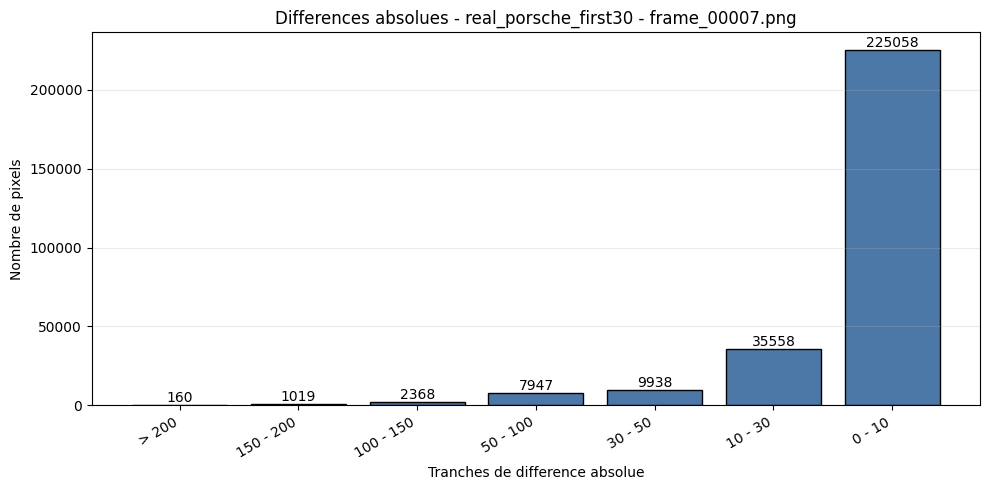

lvl:  4  initial error:  1131.1566951566945


 error improvement too small, level converged! it:  5  error:  517.57183648145  lambda:  819.2
lvl:  3  initial error:  454.8077027051741


 error improvement too small, level converged! it:  4  error:  414.8337537229519  lambda:  3518437208883.2


lvl:  2  initial error:  457.03466896575424


 error improvement too small, level converged! it:  3  error:  450.32240092492424  lambda:  0.0


[real_porsche_first30] frame 8 -> frame_00008.png | sum error = 150595424.00 | mean abs error = 9.5787 | valid pixels = 280722


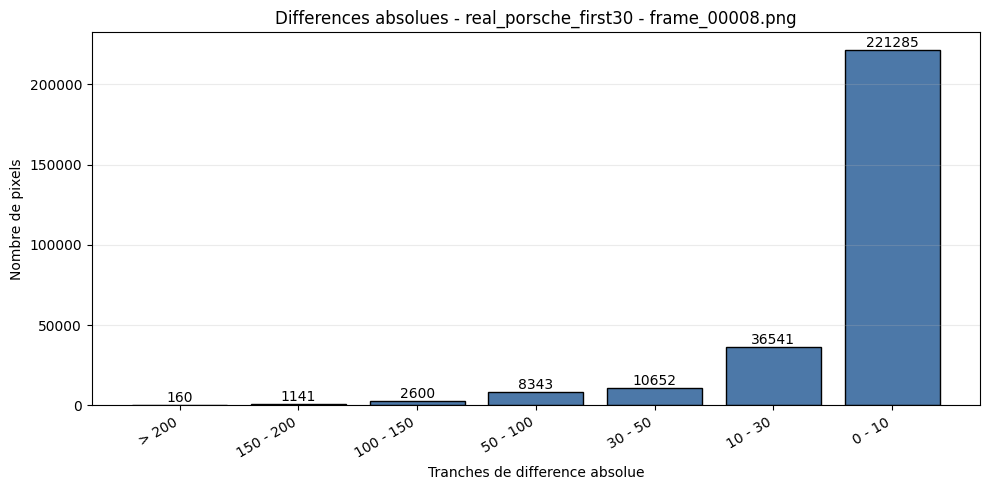

lvl:  4  initial error:  1154.2393162393155


 error improvement too small, level converged! it:  5  error:  498.8250745900103  lambda:  25.6
lvl:  3  initial error:  465.1896667949944


 error improvement too small, level converged! it:  4  error:  371.08502345546685  lambda:  0.2
lvl:  2  initial error:  413.9495110681252


 error improvement too small, level converged! it:  3  error:  406.01305408556016  lambda:  6.4


[real_porsche_first30] frame 9 -> frame_00009.png | sum error = 124461920.00 | mean abs error = 8.3217 | valid pixels = 270913


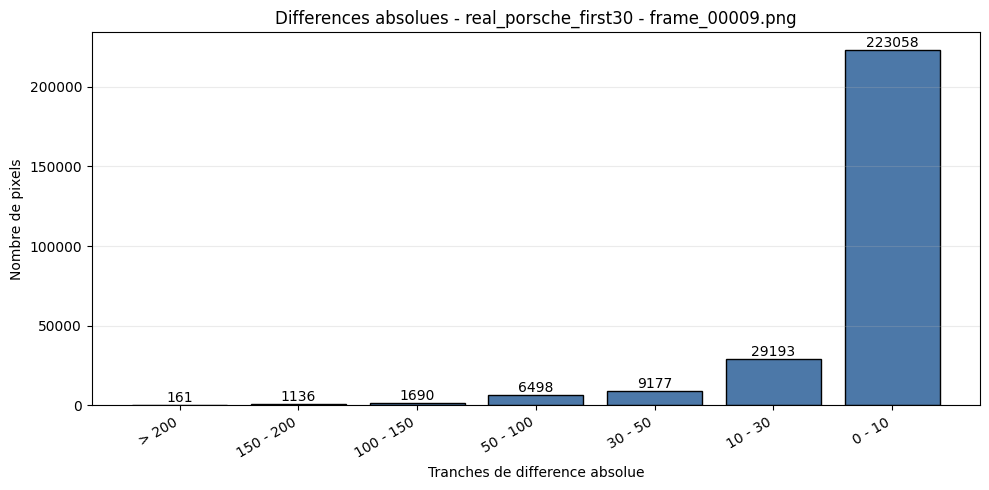

lvl:  4  initial error:  1168.4045584045575


 error improvement too small, level converged! it:  7  error:  437.2928286643154  lambda:  3.2
lvl:  3  initial error:  411.64196388572435


 error improvement too small, level converged! it:  3  error:  362.856244457834  lambda:  0.0
lvl:  2  initial error:  443.5634134301343


 error improvement too small, level converged! it:  4  error:  414.07548878795683  lambda:  7036874417766.4


[real_porsche_first30] frame 10 -> frame_00010.png | sum error = 125814088.00 | mean abs error = 8.6244 | valid pixels = 268465


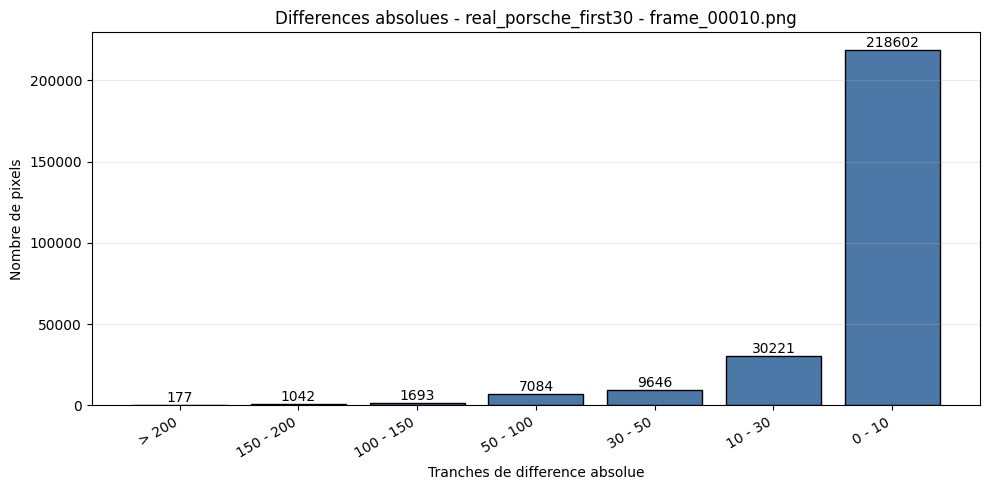

lvl:  4  initial error:  1309.5223171889832


 error improvement too small, level converged! it:  5  error:  504.42379343935016  lambda:  0.0
lvl:  3  initial error:  432.6719516966288


 error improvement too small, level converged! it:  4  error:  385.91029913518685  lambda:  7036874417766.4


lvl:  2  initial error:  444.62492063626206


 error improvement too small, level converged! it:  4  error:  423.72162093045114  lambda:  0.1


[real_porsche_first30] frame 11 -> frame_00011.png | sum error = 131052584.00 | mean abs error = 8.9272 | valid pixels = 267553


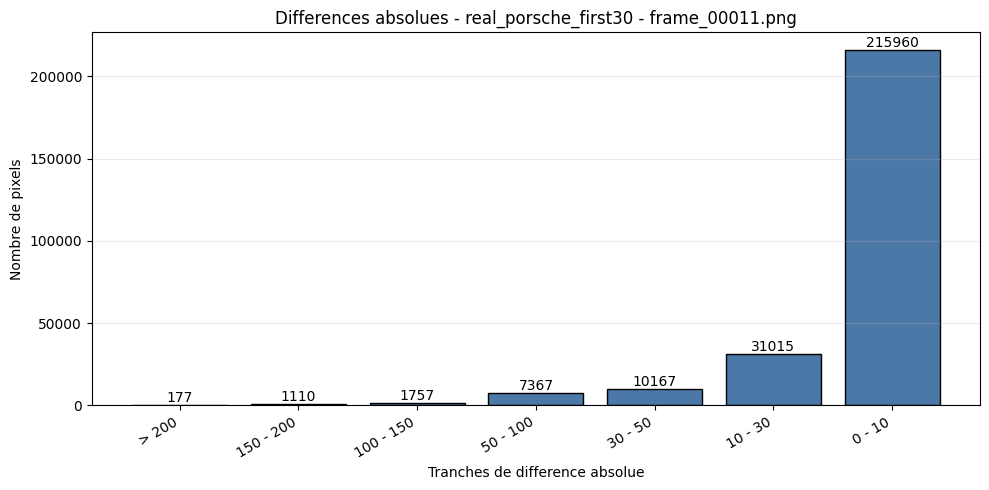

lvl:  4  initial error:  1559.6191832858485


 error improvement too small, level converged! it:  4  error:  496.3034186683668  lambda:  12.8
lvl:  3  initial error:  455.5500822072102


update too small, level converged! it:  5  error:  402.2082460094795  lambda:  56294995342131.2
lvl:  2  initial error:  474.3013664605616


 error improvement too small, level converged! it:  2  error:  471.28155116600624  lambda:  3.2


[real_porsche_first30] frame 12 -> frame_00012.png | sum error = 138395120.00 | mean abs error = 9.3840 | valid pixels = 266976


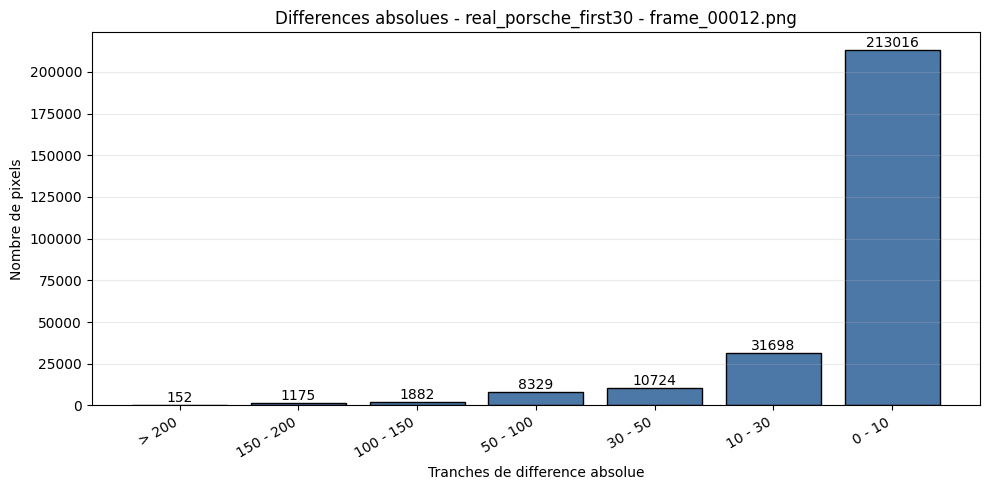

lvl:  4  initial error:  1889.7882241215568


 error improvement too small, level converged! it:  6  error:  406.64862515582325  lambda:  879609302220.8
lvl:  3  initial error:  414.16408912620926


 error improvement too small, level converged! it:  2  error:  386.55281316967256  lambda:  0.4
lvl:  2  initial error:  489.83475002754403


 error improvement too small, level converged! it:  6  error:  482.2812096335186  lambda:  0.0


[real_porsche_first30] frame 13 -> frame_00013.png | sum error = 144246256.00 | mean abs error = 9.8305 | valid pixels = 262947


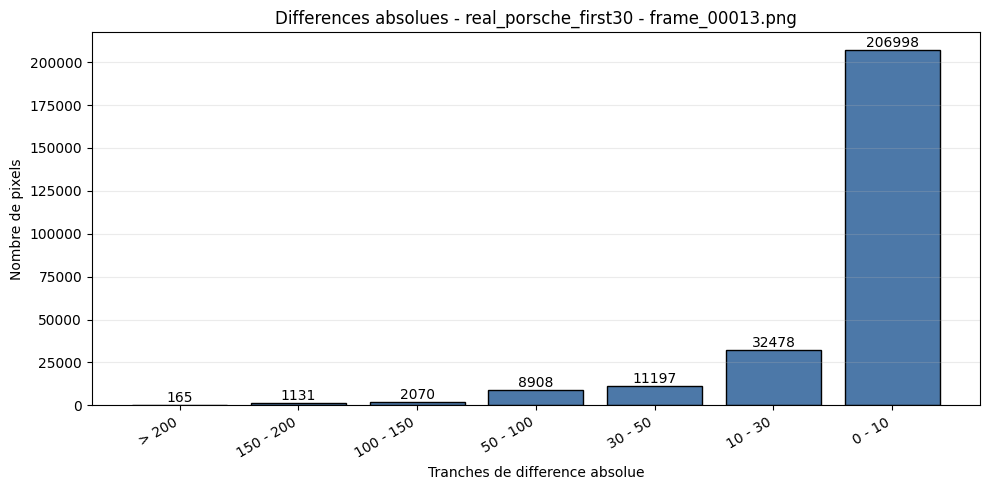

lvl:  4  initial error:  2196.9515669515663


update too small, level converged! it:  5  error:  476.45684725078587  lambda:  112589990684262.4
lvl:  3  initial error:  496.86569447529655


 error improvement too small, level converged! it:  5  error:  417.0240030485788  lambda:  0.1
lvl:  2  initial error:  509.3943949335635


 error improvement too small, level converged! it:  3  error:  491.8063656821763  lambda:  25.6


[real_porsche_first30] frame 14 -> frame_00014.png | sum error = 154135952.00 | mean abs error = 10.3162 | valid pixels = 261151


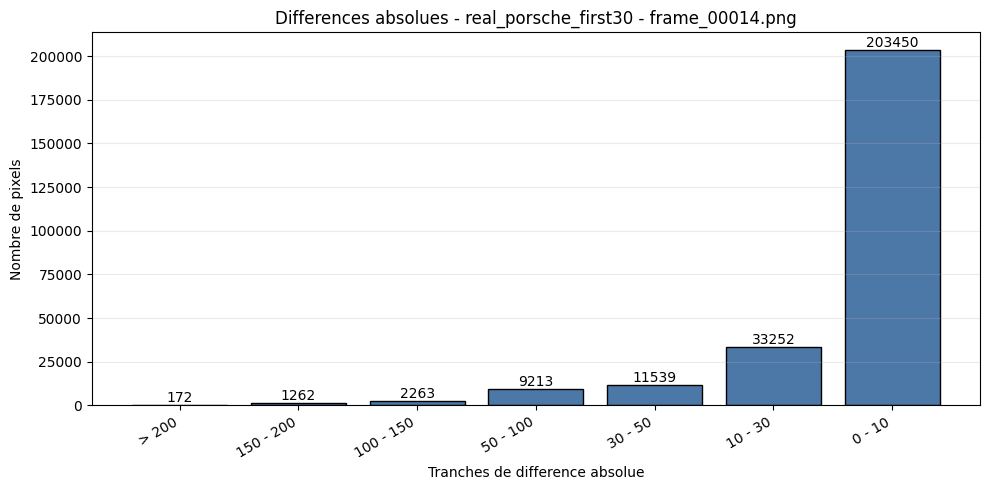

lvl:  4  initial error:  2607.823361823361


 error improvement too small, level converged! it:  6  error:  577.1246860329204  lambda:  14073748835532.8
lvl:  3  initial error:  490.8955297520246


 error improvement too small, level converged! it:  1  error:  490.5979849742832  lambda:  1.6
lvl:  2  initial error:  546.3506604565491


 error improvement too small, level converged! it:  4  error:  522.9905870963258  lambda:  0.0


[real_porsche_first30] frame 15 -> frame_00015.png | sum error = 156477088.00 | mean abs error = 10.6681 | valid pixels = 254967


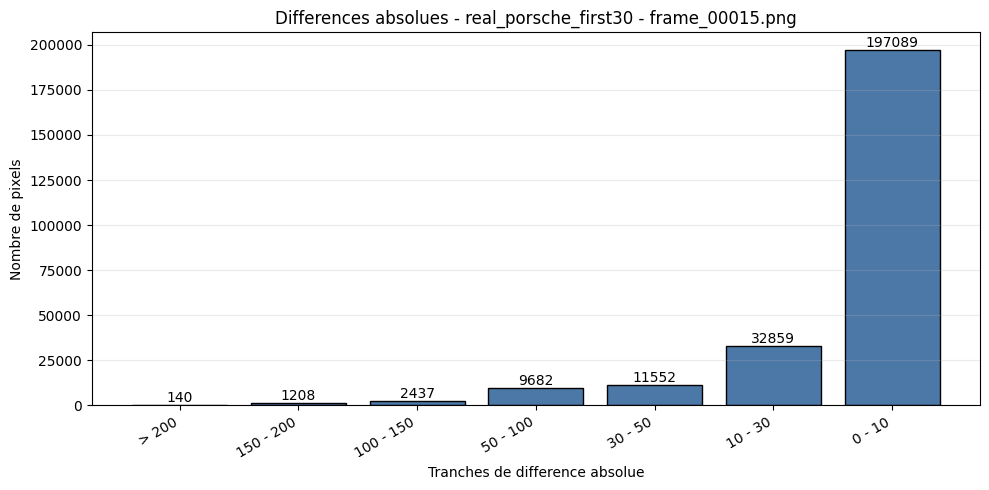

lvl:  4  initial error:  3110.394112060778


 error improvement too small, level converged! it:  4  error:  562.7074165861142  lambda:  51.2
lvl:  3  initial error:  516.3967172808037


 error improvement too small, level converged! it:  5  error:  482.91535384891534  lambda:  0.1


lvl:  2  initial error:  542.2877005285847


 error improvement too small, level converged! it:  2  error:  540.8053757325908  lambda:  0.0


[real_porsche_first30] frame 16 -> frame_00016.png | sum error = 161325584.00 | mean abs error = 10.9263 | valid pixels = 252761


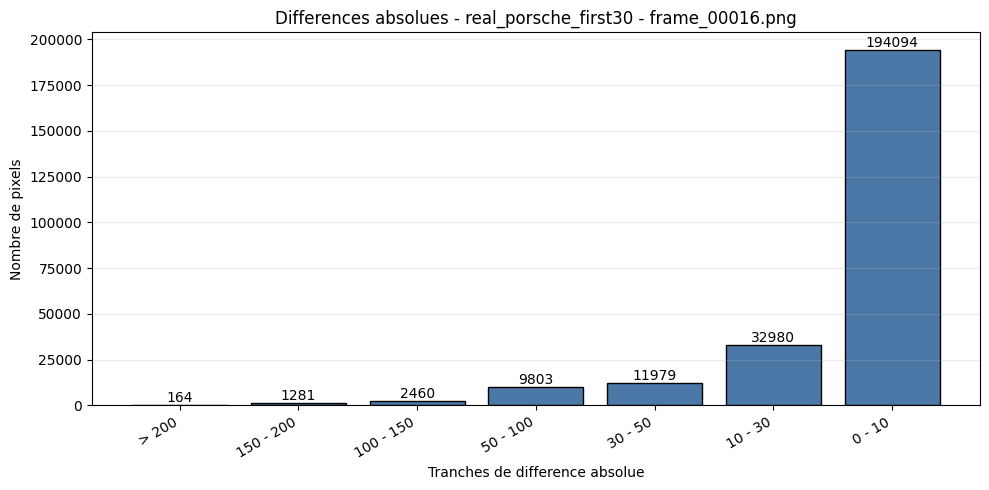

lvl:  4  initial error:  3532.3722697056023


 error improvement too small, level converged! it:  4  error:  483.2804868889366  lambda:  225179981368524.8
lvl:  3  initial error:  515.715640652155


 error improvement too small, level converged! it:  5  error:  476.58458595954255  lambda:  0.0


lvl:  2  initial error:  579.6561749506653


 error improvement too small, level converged! it:  6  error:  560.0782781971131  lambda:  0.0


[real_porsche_first30] frame 17 -> frame_00017.png | sum error = 165116480.00 | mean abs error = 11.2410 | valid pixels = 249378


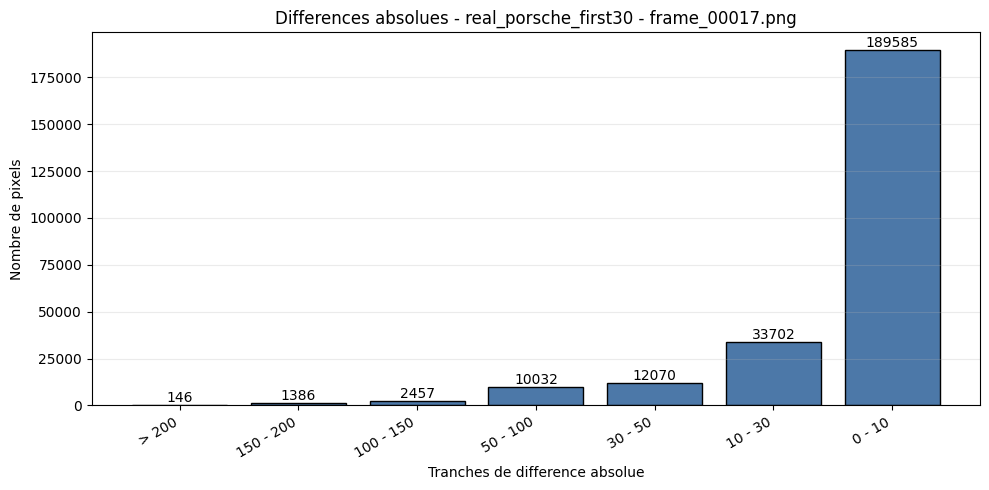

lvl:  4  initial error:  3787.0579297245954


 error improvement too small, level converged! it:  4  error:  550.8487096645673  lambda:  14073748835532.8
lvl:  3  initial error:  570.8807531790037


 error improvement too small, level converged! it:  5  error:  512.6109211991144  lambda:  0.0
lvl:  2  initial error:  617.332153459004


 error improvement too small, level converged! it:  2  error:  615.5023097575896  lambda:  0.0


[real_porsche_first30] frame 18 -> frame_00018.png | sum error = 175010016.00 | mean abs error = 11.6777 | valid pixels = 246011


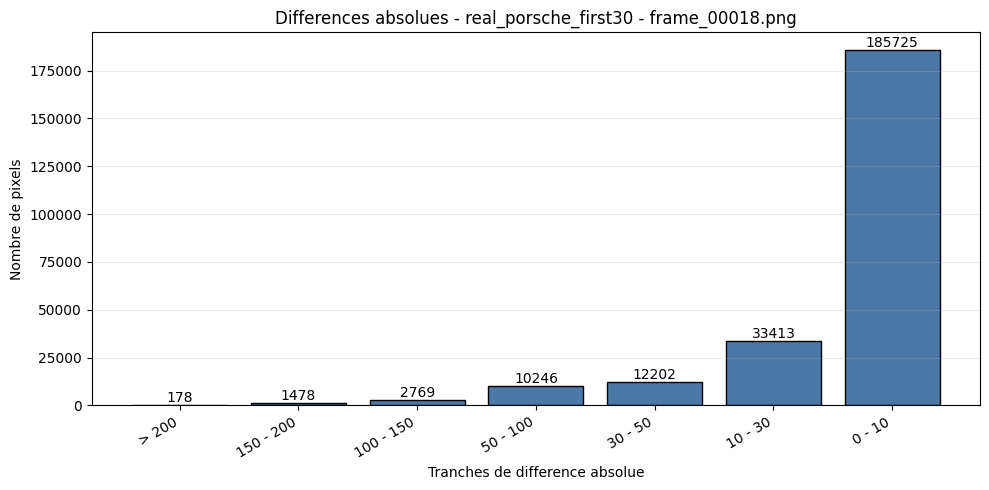

lvl:  4  initial error:  4004.8613485280143


 error improvement too small, level converged! it:  5  error:  557.333355612832  lambda:  25.6
lvl:  3  initial error:  529.074343599691


 error improvement too small, level converged! it:  1  error:  528.7417924174238  lambda:  0.0
lvl:  2  initial error:  605.8658815306067


 error improvement too small, level converged! it:  19  error:  526.9583146978753  lambda:  0.0


[real_porsche_first30] frame 19 -> frame_00019.png | sum error = 141687008.00 | mean abs error = 10.9758 | valid pixels = 233739


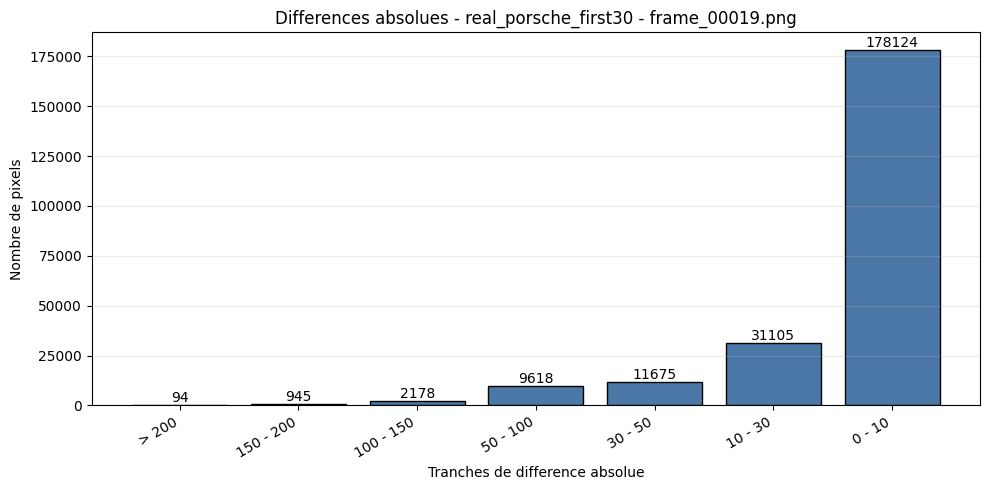

lvl:  4  initial error:  4293.35992402659


 error improvement too small, level converged! it:  6  error:  564.9350977925251  lambda:  6.4
lvl:  3  initial error:  503.2341236049325


 error improvement too small, level converged! it:  4  error:  444.4543993745943  lambda:  102.4
lvl:  2  initial error:  521.3406069224869


 error improvement too small, level converged! it:  2  error:  518.1983369669807  lambda:  1.6


[real_porsche_first30] frame 20 -> frame_00020.png | sum error = 130603248.00 | mean abs error = 10.6073 | valid pixels = 227261


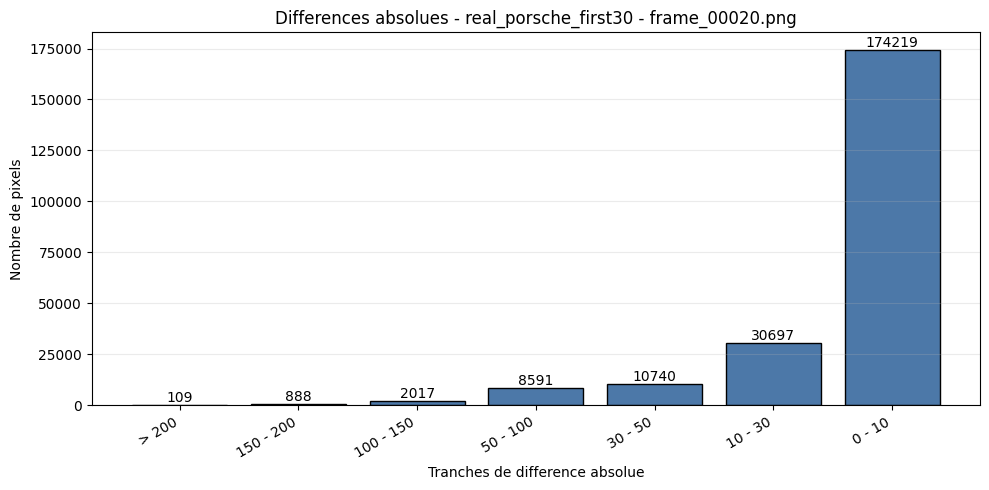

lvl:  4  initial error:  4321.430199430199


 error improvement too small, level converged! it:  6  error:  558.1636620159347  lambda:  0.1
lvl:  3  initial error:  512.5509508035925


 error improvement too small, level converged! it:  5  error:  442.3461049396908  lambda:  0.0


lvl:  2  initial error:  517.1611023773467


 error improvement too small, level converged! it:  3  error:  505.1851616281443  lambda:  0.0


[real_porsche_first30] frame 21 -> frame_00021.png | sum error = 131084208.00 | mean abs error = 10.5869 | valid pixels = 224950


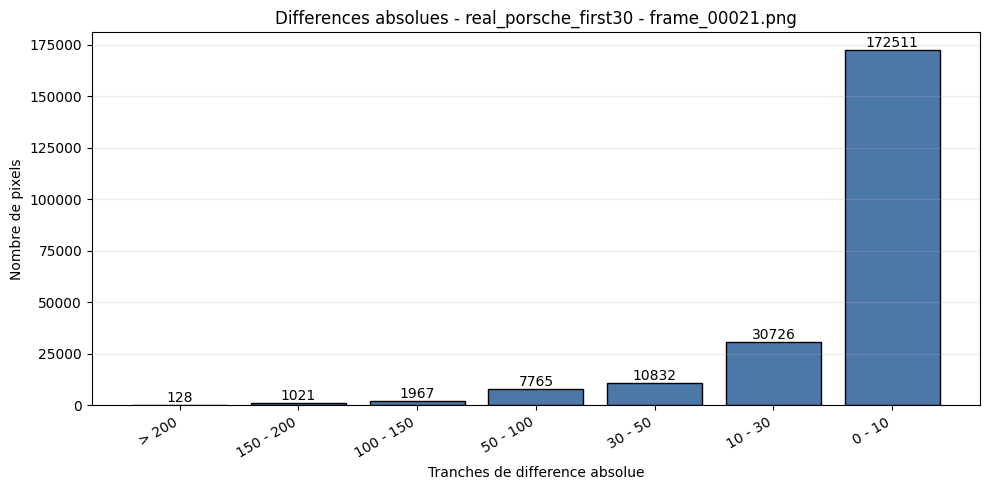

lvl:  4  initial error:  4543.550807217473


 error improvement too small, level converged! it:  5  error:  537.0100417148603  lambda:  6.4
lvl:  3  initial error:  582.8756133579362


 error improvement too small, level converged! it:  4  error:  506.933417706961  lambda:  56294995342131.2


lvl:  2  initial error:  552.9262235258426


 error improvement too small, level converged! it:  2  error:  543.4008433920523  lambda:  0.0


[real_porsche_first30] frame 22 -> frame_00022.png | sum error = 136549920.00 | mean abs error = 10.9305 | valid pixels = 223944


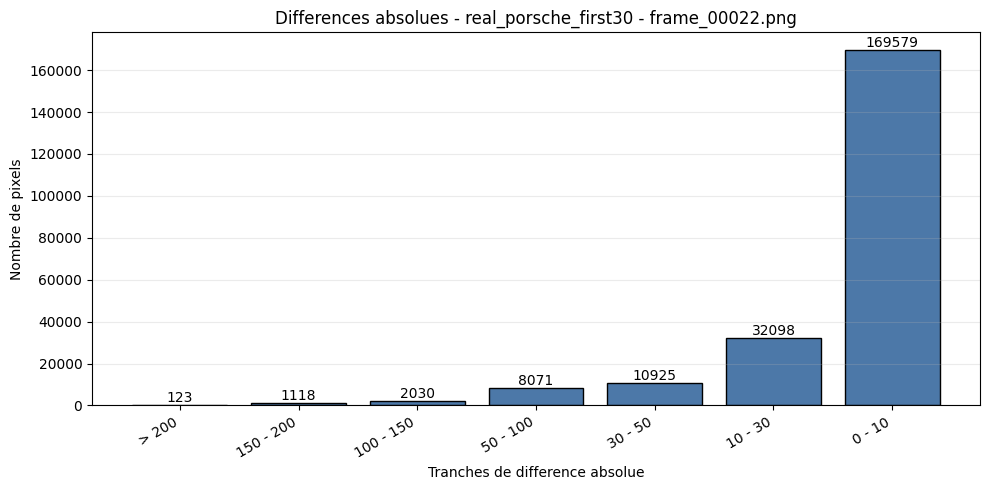

lvl:  4  initial error:  4683.948717948717


 error improvement too small, level converged! it:  5  error:  575.6775137102297  lambda:  102.4
lvl:  3  initial error:  664.1786325782491


 error improvement too small, level converged! it:  8  error:  531.1439403298507  lambda:  0.0
lvl:  2  initial error:  555.4847641426455


 error improvement too small, level converged! it:  4  error:  545.7764459158026  lambda:  0.0


[real_porsche_first30] frame 23 -> frame_00023.png | sum error = 138458016.00 | mean abs error = 11.1132 | valid pixels = 220565


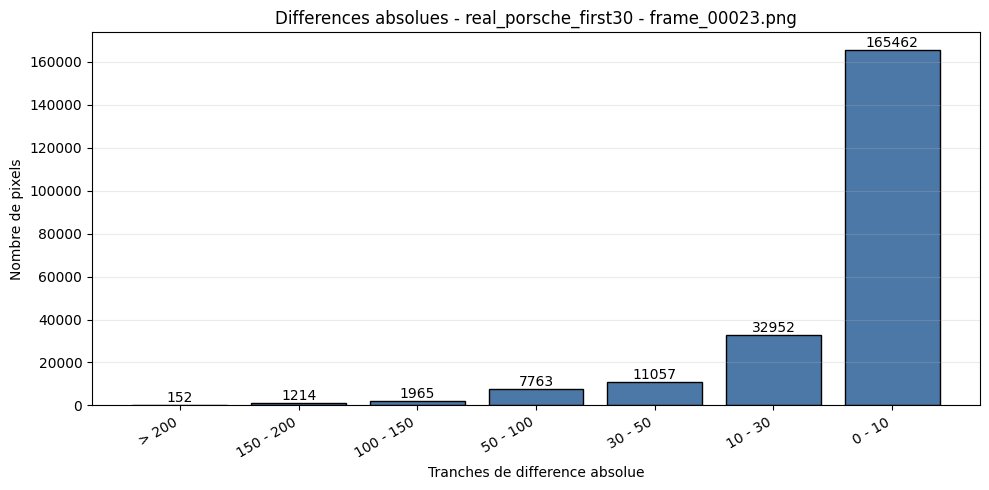

lvl:  4  initial error:  4817.139601139601


 error improvement too small, level converged! it:  7  error:  560.7363570903022  lambda:  0.2
lvl:  3  initial error:  652.0094712004804


 error improvement too small, level converged! it:  4  error:  517.0486434706307  lambda:  0.1
lvl:  2  initial error:  578.009566980547


 error improvement too small, level converged! it:  4  error:  568.7038980225094  lambda:  0.0


[real_porsche_first30] frame 24 -> frame_00024.png | sum error = 145097840.00 | mean abs error = 11.4755 | valid pixels = 217769


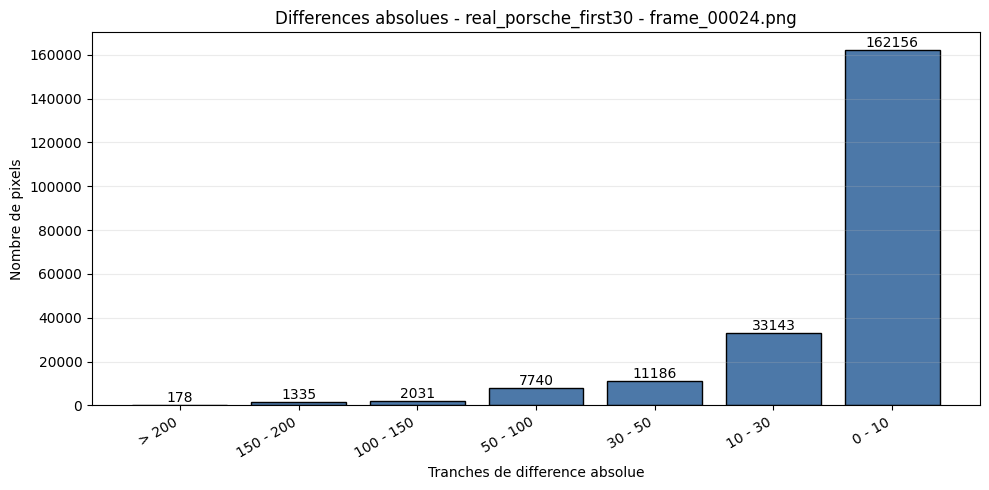

lvl:  4  initial error:  4946.13200379867


 error improvement too small, level converged! it:  4  error:  606.7786067904044  lambda:  56294995342131.2
lvl:  3  initial error:  654.5836982804946


 error improvement too small, level converged! it:  6  error:  518.6904887670707  lambda:  12.8
lvl:  2  initial error:  597.312264677955


 error improvement too small, level converged! it:  2  error:  596.0923623711336  lambda:  0.0


[real_porsche_first30] frame 25 -> frame_00025.png | sum error = 148014144.00 | mean abs error = 11.8084 | valid pixels = 215585


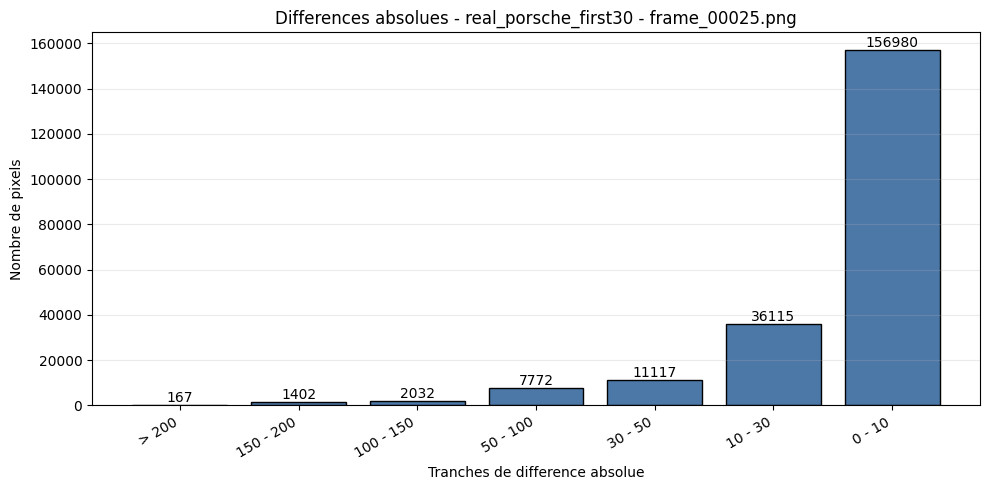

lvl:  4  initial error:  5050.051282051281


 error improvement too small, level converged! it:  5  error:  607.98506533759  lambda:  0.1
lvl:  3  initial error:  674.8303122709435


 error improvement too small, level converged! it:  4  error:  571.0389459585623  lambda:  1759218604441.6
lvl:  2  initial error:  661.7545549712017


 error improvement too small, level converged! it:  3  error:  651.5338392031227  lambda:  13743895347.2


[real_porsche_first30] frame 26 -> frame_00026.png | sum error = 156543152.00 | mean abs error = 12.4636 | valid pixels = 213602


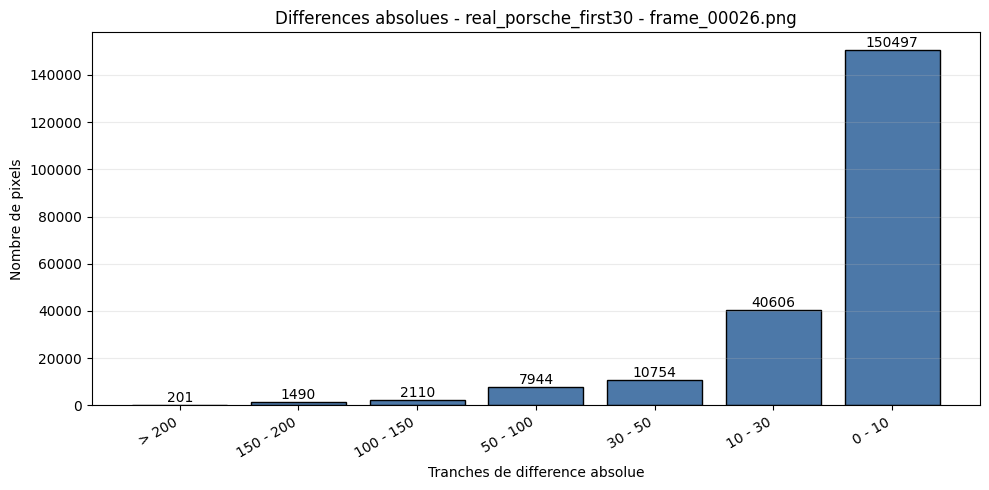

lvl:  4  initial error:  5165.46343779677


 error improvement too small, level converged! it:  5  error:  607.665654609369  lambda:  0.2
lvl:  3  initial error:  671.92874905033


 error improvement too small, level converged! it:  7  error:  625.3657783459013  lambda:  6.4
lvl:  2  initial error:  660.6967299311472


 error improvement too small, level converged! it:  3  error:  655.9116055597761  lambda:  12.8


[real_porsche_first30] frame 27 -> frame_00027.png | sum error = 159618880.00 | mean abs error = 12.7142 | valid pixels = 211394


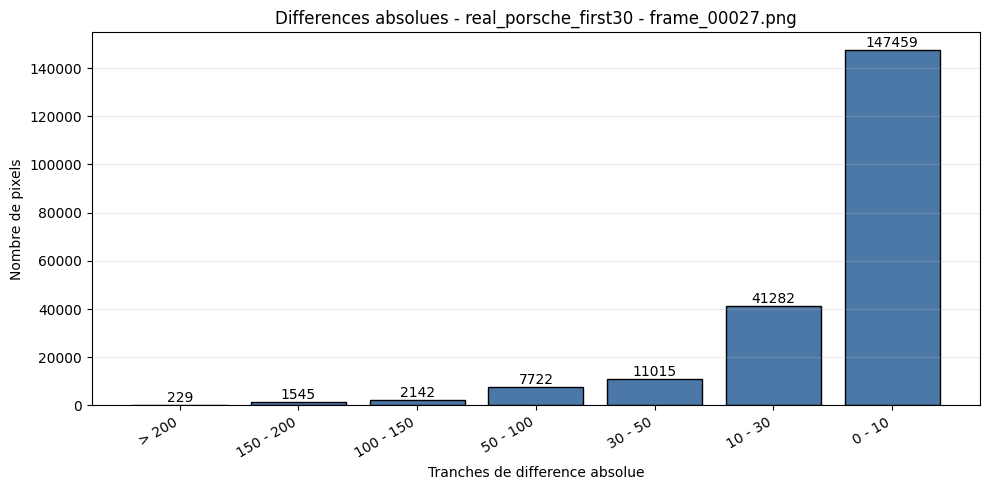

lvl:  4  initial error:  5350.563152896485


 error improvement too small, level converged! it:  5  error:  612.5768537252793  lambda:  109951162777.6
lvl:  3  initial error:  663.5928452470613


 error improvement too small, level converged! it:  3  error:  616.4081123719913  lambda:  25.6


lvl:  2  initial error:  714.5581149905756


 error improvement too small, level converged! it:  6  error:  674.0854768251813  lambda:  0.0


[real_porsche_first30] frame 28 -> frame_00028.png | sum error = 164569440.00 | mean abs error = 13.0986 | valid pixels = 209913


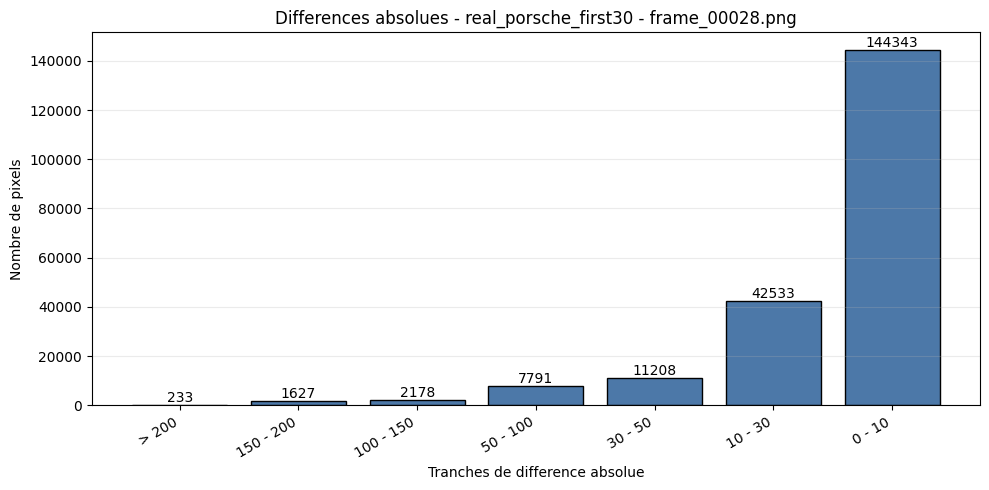

lvl:  4  initial error:  5360.789173789172


 error improvement too small, level converged! it:  5  error:  527.8978273656395  lambda:  0.2
lvl:  3  initial error:  734.245189191546


 error improvement too small, level converged! it:  3  error:  657.600009764732  lambda:  0.0
lvl:  2  initial error:  735.7793472193973


 error improvement too small, level converged! it:  7  error:  707.4196632556167  lambda:  0.1


[real_porsche_first30] frame 29 -> frame_00029.png | sum error = 170165648.00 | mean abs error = 13.4838 | valid pixels = 209547


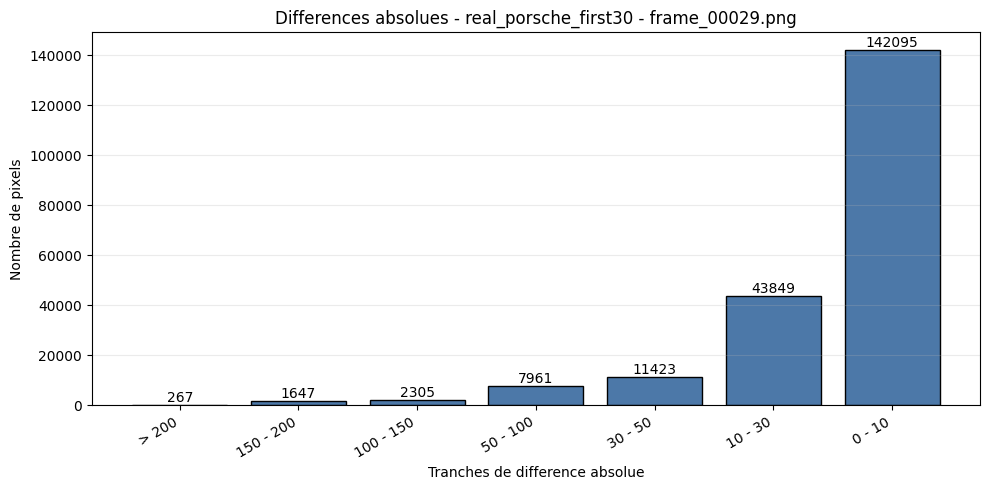

In [32]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[:30]

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "real_porsche_first30"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append(
            {
                "index": step,
                "image_path": str(image_path),
                "depth_valid_ratio": float(depth_valid_mask.mean()),
                "pose_matrix": current_frame.pose.as_matrix(),
                "photometric_error": None,
                "photometric_error_mean": None,
                "valid_pixel_count": None,
                "histogram_counts": None,
            }
        )
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append(
        {
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": photometric_error,
            "photometric_error_mean": photometric_error_mean,
            "valid_pixel_count": valid_pixel_count,
            "histogram_counts": range_counts,
        }
    )


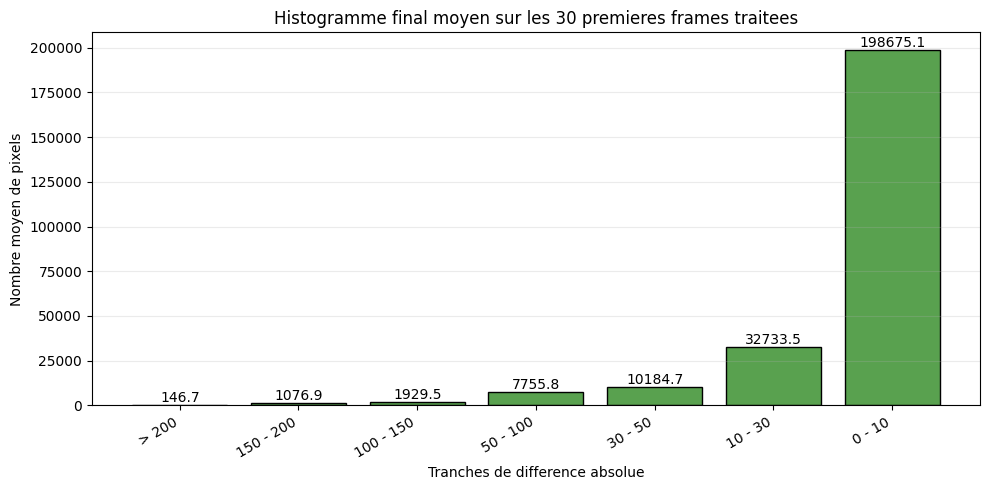

Histogramme final moyen:
     > 200 -> 146.66
  150 - 200 -> 1076.93
  100 - 150 -> 1929.52
  50 - 100 -> 7755.79
   30 - 50 -> 10184.69
   10 - 30 -> 32733.52
    0 - 10 -> 198675.07
Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\real_porsche_first30_mean_histogram.png


In [33]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur les 30 premieres frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
final_histogram_path = IMAGE_OUTPUT_DIR / "real_porsche_first30_mean_histogram.png"
plt.savefig(final_histogram_path, dpi=150, bbox_inches="tight")
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")
print(f"Image sauvegardee : {final_histogram_path}")


133395503.51724137


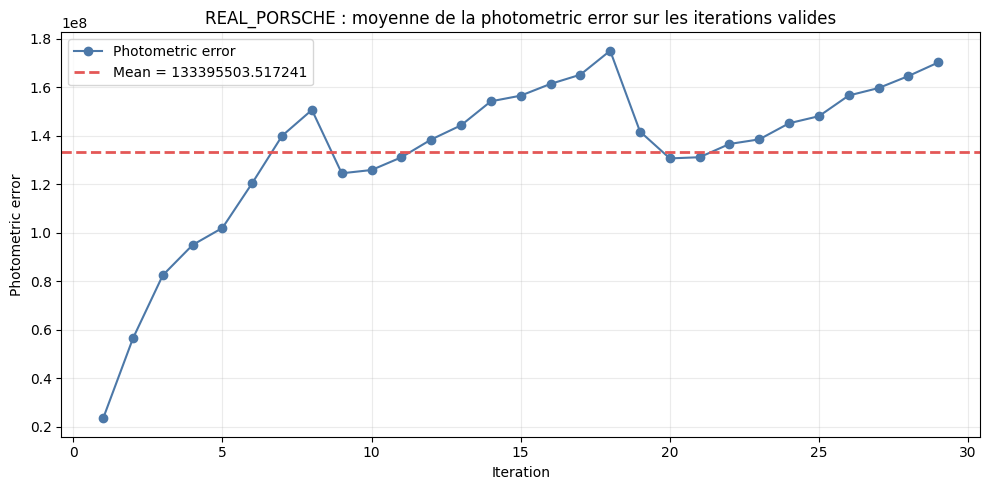

Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\real_porsche_first30_photometric_error.png


In [34]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun resultat valide disponible pour calculer la moyenne des erreurs photometriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("REAL_PORSCHE : moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
final_error_curve_path = IMAGE_OUTPUT_DIR / "real_porsche_first30_photometric_error.png"
plt.savefig(final_error_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Image sauvegardee : {final_error_curve_path}")
